# MSCS-634 Project Deliverable 1: Data Collection, Cleaning, and Exploration

**Course:** MSCS-634 – Advanced Big Data and Data Mining  
**Name:** Saru Bhandari  
**Deliverable:** 1 of 4 – Data Collection, Cleaning, and Exploration

## 1. Dataset Selection and Justification

**Dataset:** Retail Transactions Dataset (`retail_transactions_raw.csv`)

**Description:** The dataset contains 750+ individual retail purchase transactions
across 260 customers. Each row is one line-item transaction and includes customer
demographics (age, gender, state, city), product information (category, product
name), purchase details (quantity, unit price, total amount, payment method,
transaction date), and a partially-populated customer satisfaction rating.

**Why this dataset is appropriate for the project:**
- It has **14 attributes** and **750+ records**, exceeding the 8-10 attribute /
  500-record minimum.
- It mixes **numeric** (age, quantity, price, total), **categorical**
  (gender, state, category, payment method), and **datetime** (transaction date)
  fields, which supports the regression, classification, and clustering work in
  later deliverables.
- Because each transaction records a `CustomerID`, `ProductCategory`, and
  `ProductName`, the data can be grouped into **customer/date "baskets"** for
  market-basket / association rule mining (Apriori, FP-Growth) in Deliverable 3.
- It contains **realistic data-quality issues** — missing values, duplicate rows,
  inconsistently formatted state names, and a few extreme outliers — which gives
  genuine cleaning work to perform and document, rather than a dataset that is
  already clean.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)
sns.set_theme(style="whitegrid")
%matplotlib inline

## 2. Load the Dataset and Inspect Its Structure

In [2]:
df = pd.read_csv("retail_transactions_raw.csv")
print("Shape (rows, columns):", df.shape)
df.head()

Shape (rows, columns): (1038, 14)


,TransactionID,CustomerID,TransactionDate,CustomerAge,Gender,State,City,ProductCategory,ProductName,Quantity,UnitPrice,TotalAmount,PaymentMethod,CustomerSatisfaction
0,T100126,C1282,2025-08-28,56.0,Male,oh,Cincinnati,Toys,Board Game,2,164.14,328.28,PayPal,NaN
1,T100956,C1213,2025-01-16,43.0,Female,ga,Atlanta,Home & Kitchen,Blender,1,199.63,199.63,Credit Card,NaN
2,T100798,C1258,2025-02-20,27.0,Female,N.Y.,New York City,Books,Cookbook,4,52.13,208.52,Credit Card,NaN
3,T100438,C1338,2025-07-21,NaN,Female,ca,San Francisco,Books,Biography,2,118.06,236.12,Credit Card,NaN
4,T100259,C1308,2025-07-03,35.0,Male,oh,Cleveland,Sports & Outdoors,Dumbbell Set,4,119.32,477.28,Credit Card,1.0


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1038 entries, 0 to 1037
Data columns (total 14 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   TransactionID         1038 non-null   str    
 1   CustomerID            1038 non-null   str    
 2   TransactionDate       1038 non-null   str    
 3   CustomerAge           944 non-null    float64
 4   Gender                965 non-null    str    
 5   State                 1038 non-null   str    
 6   City                  1038 non-null   str    
 7   ProductCategory       1038 non-null   str    
 8   ProductName           1038 non-null   str    
 9   Quantity              1038 non-null   int64  
 10  UnitPrice             1038 non-null   float64
 11  TotalAmount           1038 non-null   float64
 12  PaymentMethod         1038 non-null   str    
 13  CustomerSatisfaction  333 non-null    float64
dtypes: float64(4), int64(1), str(9)
memory usage: 113.7 KB


In [4]:
df.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
TransactionID,1038,1000,T100113,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN
CustomerID,1038,319,C1249,10,NaN,NaN,NaN,NaN,NaN,NaN,NaN
TransactionDate,1038,288,2025-06-11,8,NaN,NaN,NaN,NaN,NaN,NaN,NaN
CustomerAge,944.0,NaN,NaN,NaN,45.833686,15.563604,18.0,33.0,46.0,59.0,74.0
Gender,965,2,Male,486,NaN,NaN,NaN,NaN,NaN,NaN,NaN
State,1038,32,GA,48,NaN,NaN,NaN,NaN,NaN,NaN,NaN
City,1038,30,Erie,53,NaN,NaN,NaN,NaN,NaN,NaN,NaN
ProductCategory,1038,7,Sports & Outdoors,166,NaN,NaN,NaN,NaN,NaN,NaN,NaN
ProductName,1038,35,Bicycle Helmet,42,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Quantity,1038.0,NaN,NaN,NaN,4.072254,11.044033,1.0,2.0,3.0,4.0,150.0


In [5]:
print("Missing values per column:")
print(df.isnull().sum())
print("\nMissing value percentage per column:")
print((df.isnull().sum() / len(df) * 100).round(1))

Missing values per column:
TransactionID             0
CustomerID                0
TransactionDate           0
CustomerAge              94
Gender                   73
State                     0
City                      0
ProductCategory           0
ProductName               0
Quantity                  0
UnitPrice                 0
TotalAmount               0
PaymentMethod             0
CustomerSatisfaction    705
dtype: int64

Missing value percentage per column:
TransactionID            0.0
CustomerID               0.0
TransactionDate          0.0
CustomerAge              9.1
Gender                   7.0
State                    0.0
City                     0.0
ProductCategory          0.0
ProductName              0.0
Quantity                 0.0
UnitPrice                0.0
TotalAmount              0.0
PaymentMethod            0.0
CustomerSatisfaction    67.9
dtype: float64


In [6]:
print("Number of exact duplicate rows:", df.duplicated().sum())

Number of exact duplicate rows: 38


In [7]:
print("Unique values in 'State' column (note the inconsistent formatting):")
print(sorted(df['State'].unique()))

Unique values in 'State' column (note the inconsistent formatting):
['CA', 'Calif.', 'California', 'FL', 'Florida', 'GA', 'Georgia', 'IL', 'Illinois', 'N.Y.', 'NC', 'NY', 'New York', 'North Carolina', 'OH', 'Ohio', 'PA', 'Pennsylvania', 'TX', 'Texas', 'WA', 'Washington', 'ca', 'fl', 'ga', 'il', 'nc', 'ny', 'oh', 'pa', 'tx', 'wa']


## 3. Data Cleaning

We address the issues surfaced above in four steps: missing values, duplicates,
inconsistent categorical labels, and noisy/outlier values.

### 3.1 Handling Missing Values

Strategy, chosen per column based on how much data is missing and what type it is:
- **`CustomerSatisfaction`** is missing for roughly two-thirds of rows. Imputing
  a rating for that many records would manufacture data that was never
  collected, so **the column is dropped entirely**.
- **`CustomerAge`** (numeric, ~9% missing) is imputed with the **median** age,
  which is robust to outliers/skew.
- **`Gender`** (categorical, ~7% missing) is imputed with the **mode**
  (most frequently occurring category).

In [8]:
missing_pct = df.isnull().mean() * 100
cols_to_drop = missing_pct[missing_pct > 50].index.tolist()
print("Columns dropped for excessive missingness (>50%):", cols_to_drop)
df = df.drop(columns=cols_to_drop)

age_median = df['CustomerAge'].median()
df['CustomerAge'] = df['CustomerAge'].fillna(age_median)
print(f"CustomerAge missing values filled with median = {age_median}")

gender_mode = df['Gender'].mode()[0]
df['Gender'] = df['Gender'].fillna(gender_mode)
print(f"Gender missing values filled with mode = '{gender_mode}'")

print("\nRemaining missing values:\n", df.isnull().sum())

Columns dropped for excessive missingness (>50%): ['CustomerSatisfaction']
CustomerAge missing values filled with median = 46.0
Gender missing values filled with mode = 'Male'

Remaining missing values:
 TransactionID      0
CustomerID         0
TransactionDate    0
CustomerAge        0
Gender             0
State              0
City               0
ProductCategory    0
ProductName        0
Quantity           0
UnitPrice          0
TotalAmount        0
PaymentMethod      0
dtype: int64


### 3.2 Removing Duplicate Records

Exact duplicate rows were injected by repeated transaction exports and would
bias any downstream model (e.g., over-weighting certain customers/products).
They are removed, keeping the first occurrence.

In [9]:
before = len(df)
df = df.drop_duplicates()
after = len(df)
print(f"Removed {before - after} duplicate rows ({before} -> {after}).")

Removed 38 duplicate rows (1038 -> 1000).


### 3.3 Correcting Inconsistent Data

The `State` column contains multiple representations of the same state
(e.g., `'NY'`, `'New York'`, `'ny'`, `'N.Y.'`). These are standardized to the
two-letter USPS abbreviation so the column can be used reliably in grouping,
encoding, or filtering.

In [10]:
state_standardize = {
    'ny': 'NY', 'new york': 'NY', 'n.y.': 'NY',
    'ca': 'CA', 'california': 'CA', 'calif.': 'CA',
    'tx': 'TX', 'texas': 'TX',
    'fl': 'FL', 'florida': 'FL',
    'il': 'IL', 'illinois': 'IL',
    'wa': 'WA', 'washington': 'WA',
    'oh': 'OH', 'ohio': 'OH',
    'ga': 'GA', 'georgia': 'GA',
    'nc': 'NC', 'north carolina': 'NC',
    'pa': 'PA', 'pennsylvania': 'PA',
}

print("Before standardization:", sorted(df['State'].unique()))
df['State'] = df['State'].str.strip().str.lower().map(state_standardize)
print("After standardization:", sorted(df['State'].unique()))
print("\nAny unmapped/missing states after standardization?", df['State'].isnull().sum())

Before standardization: ['CA', 'Calif.', 'California', 'FL', 'Florida', 'GA', 'Georgia', 'IL', 'Illinois', 'N.Y.', 'NC', 'NY', 'New York', 'North Carolina', 'OH', 'Ohio', 'PA', 'Pennsylvania', 'TX', 'Texas', 'WA', 'Washington', 'ca', 'fl', 'ga', 'il', 'nc', 'ny', 'oh', 'pa', 'tx', 'wa']
After standardization: ['CA', 'FL', 'GA', 'IL', 'NC', 'NY', 'OH', 'PA', 'TX', 'WA']

Any unmapped/missing states after standardization? 0


### 3.4 Identifying and Addressing Noisy Data (Outliers)

`Quantity` and `UnitPrice` contain a small number of extreme values consistent
with data-entry errors (e.g., a quantity of 90 units on a single retail
transaction, or a unit price far outside the normal range for the product
category). We use the **IQR (interquartile range) method** to flag these as
outliers, and cap them at the IQR fences (winsorizing) rather than deleting
the rows, so we keep the transaction record while removing the distortion.

In [11]:
def iqr_bounds(series, k=1.5):
    q1, q3 = series.quantile(0.25), series.quantile(0.75)
    iqr = q3 - q1
    return q1 - k * iqr, q3 + k * iqr

for col in ['Quantity', 'UnitPrice']:
    low, high = iqr_bounds(df[col])
    n_outliers = ((df[col] < low) | (df[col] > high)).sum()
    print(f"{col}: IQR bounds = [{low:.2f}, {high:.2f}]  -> {n_outliers} outlier(s) capped")
    df[col] = df[col].clip(lower=low, upper=high)

# Recompute TotalAmount so it stays consistent with the capped Quantity/UnitPrice
df['TotalAmount'] = (df['Quantity'] * df['UnitPrice']).round(2)
df[['Quantity', 'UnitPrice', 'TotalAmount']].describe()

Quantity: IQR bounds = [-1.00, 7.00]  -> 14 outlier(s) capped
UnitPrice: IQR bounds = [-103.63, 337.57]  -> 13 outlier(s) capped


,Quantity,UnitPrice,TotalAmount
count,1000.000000,1000.000000,1000.000000
mean,2.949000,117.410890,348.952270
std,1.461004,66.265304,289.299792
min,1.000000,8.110000,8.110000
25%,2.000000,61.820000,133.427500
50%,3.000000,113.270000,275.350000
75%,4.000000,172.120000,483.225000
max,7.000000,337.570000,2362.990000


### 3.5 Final Cleaned Dataset

In [12]:
df['TransactionDate'] = pd.to_datetime(df['TransactionDate'])
print("Final cleaned shape:", df.shape)
df.to_csv("retail_transactions_cleaned.csv", index=False)
df.head()

Final cleaned shape: (1000, 13)


,TransactionID,CustomerID,TransactionDate,CustomerAge,Gender,State,City,ProductCategory,ProductName,Quantity,UnitPrice,TotalAmount,PaymentMethod
0,T100126,C1282,2025-08-28,56.0,Male,OH,Cincinnati,Toys,Board Game,2,164.14,328.28,PayPal
1,T100956,C1213,2025-01-16,43.0,Female,GA,Atlanta,Home & Kitchen,Blender,1,199.63,199.63,Credit Card
2,T100798,C1258,2025-02-20,27.0,Female,NY,New York City,Books,Cookbook,4,52.13,208.52,Credit Card
3,T100438,C1338,2025-07-21,46.0,Female,CA,San Francisco,Books,Biography,2,118.06,236.12,Credit Card
4,T100259,C1308,2025-07-03,35.0,Male,OH,Cleveland,Sports & Outdoors,Dumbbell Set,4,119.32,477.28,Credit Card


## 4. Exploratory Data Analysis (EDA)

### 4.1 Distributions of Key Numeric Fields

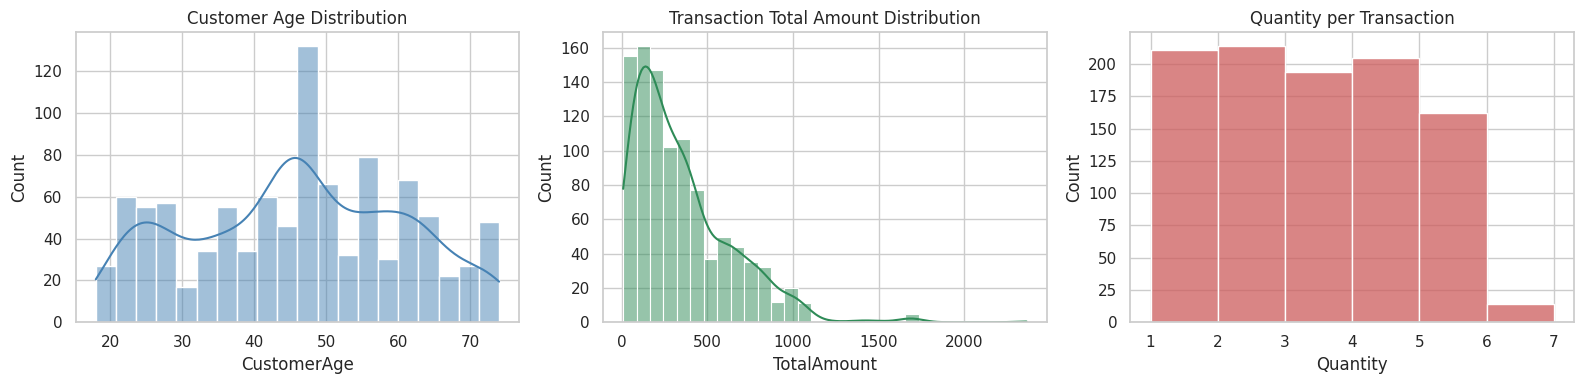

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
sns.histplot(df['CustomerAge'], bins=20, kde=True, ax=axes[0], color='steelblue')
axes[0].set_title('Customer Age Distribution')

sns.histplot(df['TotalAmount'], bins=30, kde=True, ax=axes[1], color='seagreen')
axes[1].set_title('Transaction Total Amount Distribution')

sns.histplot(df['Quantity'], bins=range(1, 8), ax=axes[2], color='indianred')
axes[2].set_title('Quantity per Transaction')
plt.tight_layout()
plt.show()

### 4.2 Outlier Check After Cleaning (Boxplots)

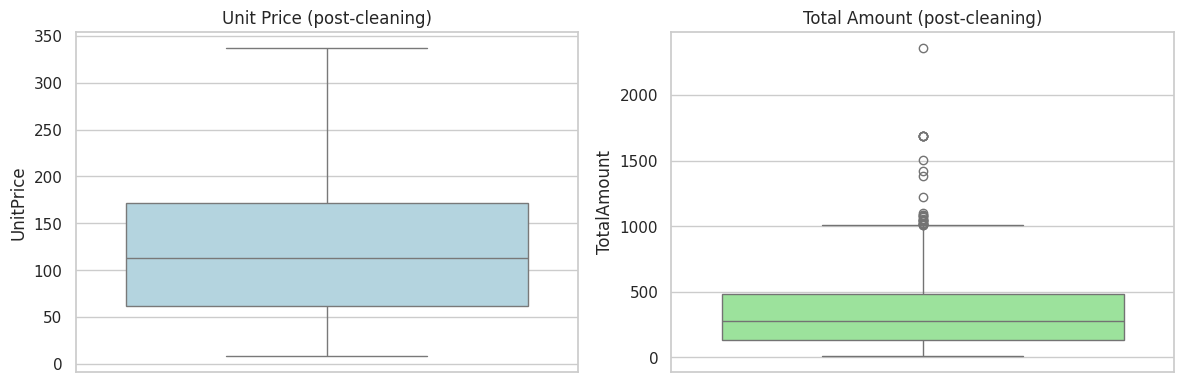

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.boxplot(y=df['UnitPrice'], ax=axes[0], color='lightblue')
axes[0].set_title('Unit Price (post-cleaning)')

sns.boxplot(y=df['TotalAmount'], ax=axes[1], color='lightgreen')
axes[1].set_title('Total Amount (post-cleaning)')
plt.tight_layout()
plt.show()

### 4.3 Categorical Feature Relationships

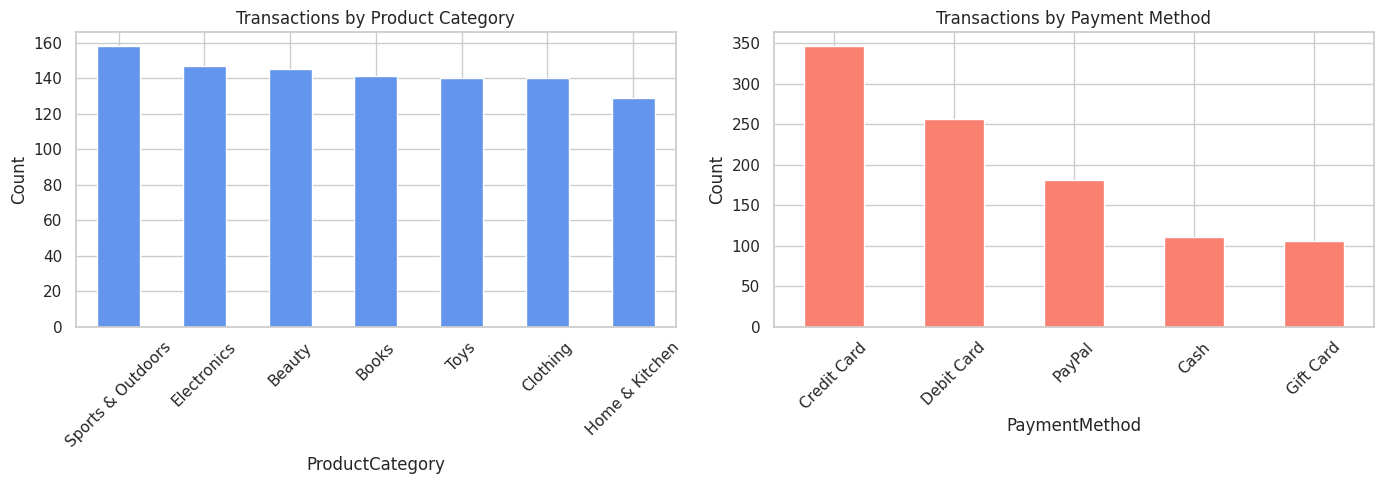

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
df['ProductCategory'].value_counts().plot(kind='bar', ax=axes[0], color='cornflowerblue')
axes[0].set_title('Transactions by Product Category')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=45)

df['PaymentMethod'].value_counts().plot(kind='bar', ax=axes[1], color='salmon')
axes[1].set_title('Transactions by Payment Method')
axes[1].set_ylabel('Count')
axes[1].tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

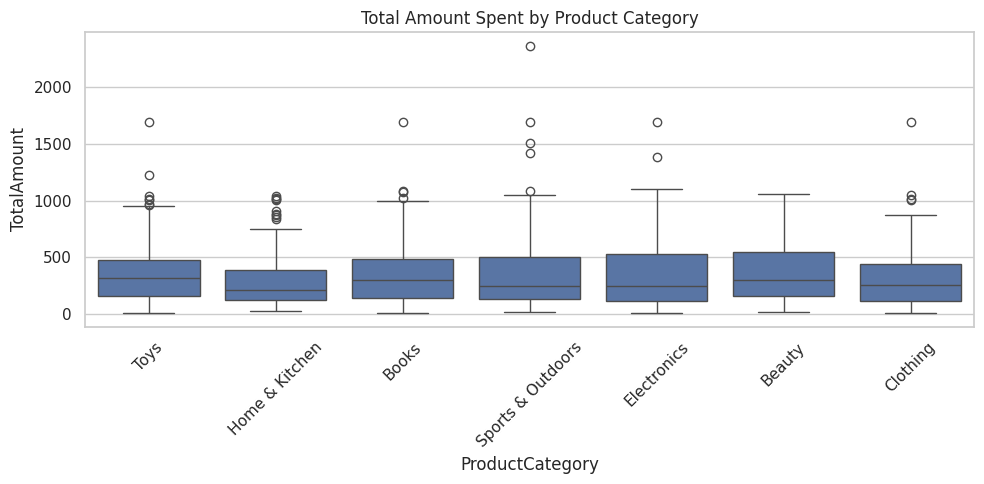

In [16]:
plt.figure(figsize=(10, 5))
sns.boxplot(data=df, x='ProductCategory', y='TotalAmount')
plt.xticks(rotation=45)
plt.title('Total Amount Spent by Product Category')
plt.tight_layout()
plt.show()

### 4.4 Correlation Among Numeric Features

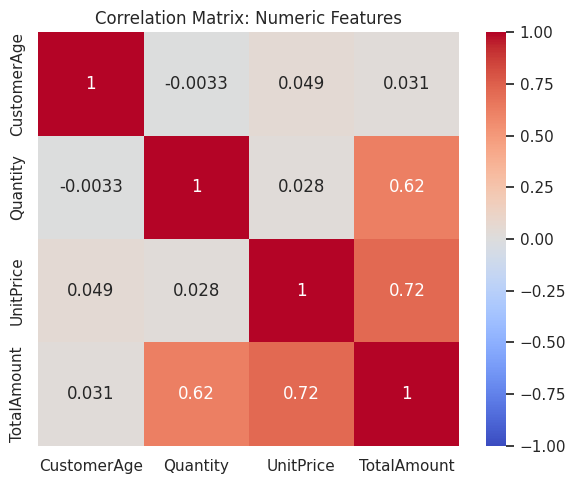

In [17]:
numeric_cols = ['CustomerAge', 'Quantity', 'UnitPrice', 'TotalAmount']
corr = df[numeric_cols].corr()

plt.figure(figsize=(6, 5))
sns.heatmap(corr, annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Correlation Matrix: Numeric Features')
plt.tight_layout()
plt.show()

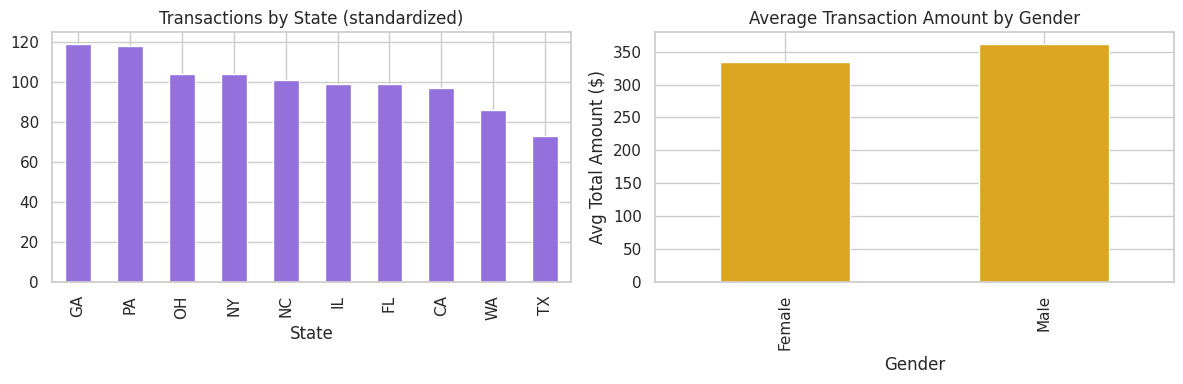

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
state_counts = df['State'].value_counts()
state_counts.plot(kind='bar', ax=axes[0], color='mediumpurple')
axes[0].set_title('Transactions by State (standardized)')

df.groupby('Gender')['TotalAmount'].mean().plot(kind='bar', ax=axes[1], color='goldenrod')
axes[1].set_title('Average Transaction Amount by Gender')
axes[1].set_ylabel('Avg Total Amount ($)')
plt.tight_layout()
plt.show()

## 5. Insights from EDA and Implications for Future Modeling

- **Product category and pricing spread:** `TotalAmount` varies noticeably by
  `ProductCategory` (see boxplot above), suggesting product category will be a
  useful predictor/feature for a future regression model of transaction value,
  and a natural grouping variable for clustering customers by spend profile.
- **Weak linear correlation among numeric features:** `CustomerAge` shows
  little linear correlation with `Quantity`, `UnitPrice`, or `TotalAmount`.
  This suggests age alone will not be a strong linear regression predictor,
  and that non-linear or interaction features (e.g., age × category) may be
  needed in Deliverable 2.
- **Quantity and UnitPrice jointly drive TotalAmount** almost by definition
  (`TotalAmount = Quantity × UnitPrice`), so for regression modeling we will
  need to be careful not to include all three as independent features
  simultaneously (multicollinearity/target leakage).
- **Category and payment-method distributions are uneven** (some categories
  and payment methods are far more common than others), which is useful
  context for classification model evaluation later — accuracy alone won't be
  a reliable metric if a target class is imbalanced.
- **Transactional structure is preserved:** because `CustomerID`,
  `ProductCategory`, and `ProductName` remain intact after cleaning, the
  cleaned dataset can be grouped into per-customer/per-date "baskets" for
  association rule mining (Apriori/FP-Growth) in Deliverable 3.
- **Cleaning materially changed the data:** roughly two-thirds of rows lost
  their `CustomerSatisfaction` value (column dropped), ~9%/~7% of rows had
  `CustomerAge`/`Gender` imputed, duplicate rows were removed, 10 inconsistent
  state spellings were consolidated into 10 standard codes, and a handful of
  extreme `Quantity`/`UnitPrice` outliers were capped — all of which will
  reduce bias in any model trained on this data going forward.